【📌 制造过程质量分析项目启动】
✅ 数据读取成功！

--- 数据基础信息 ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   machine_speed_rpm     1000 non-null   int64
 1   humidity_percent      1000 non-null   int64
 2   production_count      1000 non-null   int64
 3   defect_count          1000 non-null   int64
 4   maintenance_required  1000 non-null   int64
dtypes: int64(5)
memory usage: 39.2 KB
None

--- 缺失值检查 ---
machine_speed_rpm       0
humidity_percent        0
production_count        0
defect_count            0
maintenance_required    0
dtype: int64

--- 数据预览 ---
   machine_speed_rpm  humidity_percent  production_count  defect_count  \
0               1926                59                80            11   
1               1660                64               198            11   
2               2094                50                87             6 

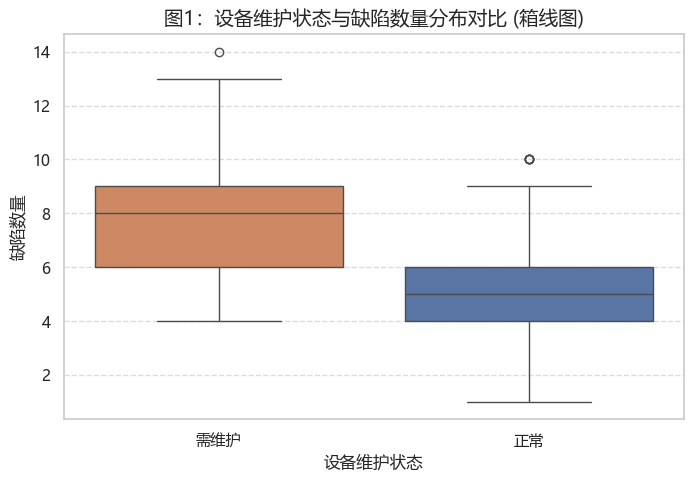

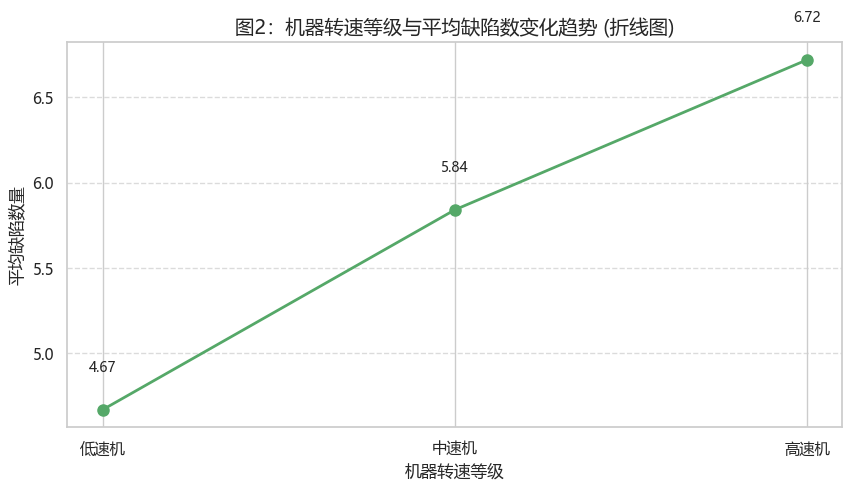

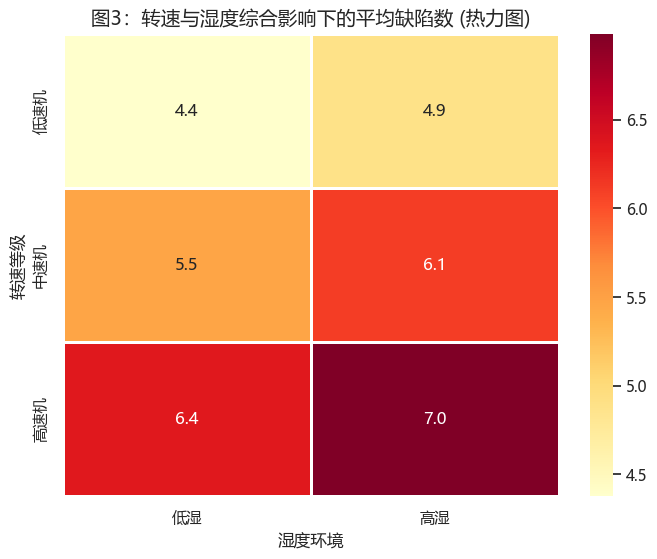


【📊 制造质量数据分析业务报告】
1. 整体大盘：生产线的综合不良率为 **4.24%**。
2. 设备维护预警：箱线图显示，需要维护的设备不仅缺陷中位数更高，且极值（严重缺陷）频发，必须立即落实保养。
3. 转速趋势：折线图表明，随着转速提升，缺陷数量呈明显线性上升，高转速机台需加强监控。
4. 环境交互：热力图揭示，在高转速且高湿度的极端组合下，平均缺陷数达到了最高点，这是车间的‘高危时刻’。

🔧 立即执行的改进建议：
① 优先对‘需维护’设备进行停机检修，消除最大的缺陷隐患。
② 对高转速设备制定更频繁的巡检或延长冷却时间。
③ 生产线需配备除湿设备，严格将湿度控制在 50% 以下，尤其是高速运转时段。

✅ 三张图表（1_boxplot.png, 2_line_chart.png, 3_heatmap.png）已成功保存到当前目录！


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ================= 0. 全局设置 =================
# 解决Matplotlib中文显示问题
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei'] 
plt.rcParams['axes.unicode_minus'] = False
# 设置Seaborn图表风格
sns.set_theme(style="whitegrid", font='Microsoft YaHei')

print("="*50)
print("【📌 制造过程质量分析项目启动】")
print("="*50)

# ================= 1. 数据读取与初始探查 =================
try:
    df = pd.read_csv("manufacture_quality_data.csv")
    print("✅ 数据读取成功！")
except FileNotFoundError:
    print("❌ 找不到文件！请确保 manufacture_quality_data.csv 在代码同级目录下。")
    exit()

print("\n--- 数据基础信息 ---")
print(df.info())
print("\n--- 缺失值检查 ---")
print(df.isnull().sum())
print("\n--- 数据预览 ---")
print(df.head())

# ================= 2. 数据预处理 =================
# 1. 删除完全重复的行
df = df.drop_duplicates()
print(f"✅ 清洗完成，剩余行数：{len(df)}")

# 2. 为了后续图表更直观，我们进行数据分箱（离散化）
# 将连续转速划分为三个类别
df['转速等级'] = pd.cut(df['machine_speed_rpm'], 
                         bins=[0, 1200, 1700, 3000], 
                         labels=['低速机', '中速机', '高速机'])
# 将湿度划分为两类
df['湿度环境'] = df['humidity_percent'].apply(lambda x: '高湿' if x >= 50 else '低湿')
# 维护状态转为文字标签
df['维护状态'] = df['maintenance_required'].map({0: '正常', 1: '需维护'})

# ================= 3. 核心指标计算 =================
print("\n--- 关键指标计算 ---")
total_production = df['production_count'].sum()
total_defect = df['defect_count'].sum()
overall_defect_rate = total_defect / total_production
print(f"· 总产量：{total_production}")
print(f"· 总缺陷：{total_defect}")
print(f"· 整体不良率：{overall_defect_rate:.2%}")

# ================= 4. 生成三张不同类型的PNG图片 =================

# --- 图片1：箱线图（Boxplot）--- 
# 业务意图：对比“维护状态”下的缺陷分布差异（看中位数和异常值）
plt.figure(figsize=(8, 5))

# 新写法：将 x 轴变量同时赋给 hue，并设置 legend=False
# 这样可以保留原本的配色效果，同时消除未来的版本警告
sns.boxplot(x='维护状态', y='defect_count', data=df, 
            hue='维护状态',                # 👈 关键修改：加上 hue
            palette={'正常': '#4c72b0', '需维护': '#dd8452'},
            legend=False)                  # 👈 关键修改：关闭多余的图例

plt.title('图1：设备维护状态与缺陷数量分布对比 (箱线图)', fontsize=14)
plt.xlabel('设备维护状态')
plt.ylabel('缺陷数量')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 保存图片
plt.savefig('1_boxplot.png', dpi=300, bbox_inches='tight')
plt.show()

# --- 图片2：折线图（Line Chart）---
# 业务意图：展示不同转速下，平均缺陷数的变化趋势
plt.figure(figsize=(10, 5))
# 计算各转速等级下的平均缺陷数
speed_avg = df.groupby('转速等级', observed=False)['defect_count'].mean()
# 画折线图
plt.plot(speed_avg.index, speed_avg.values, marker='o', linestyle='-', linewidth=2, color='#55a868', markersize=8)
plt.title('图2：机器转速等级与平均缺陷数变化趋势 (折线图)', fontsize=14)
plt.xlabel('机器转速等级')
plt.ylabel('平均缺陷数量')
# 在折线点上方添加数值标签
for x, y in zip(speed_avg.index, speed_avg.values):
    plt.text(x, y + 0.2, f'{y:.2f}', ha='center', va='bottom', fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
# 保存图片
plt.savefig('2_line_chart.png', dpi=300, bbox_inches='tight')
plt.show()

# --- 图片3：热力图（Heatmap）---
# 业务意图：通过热力图展示“转速等级”与“湿度环境”交叉下的平均缺陷密集程度
plt.figure(figsize=(8, 6))
# 计算交叉表
pivot_data = df.pivot_table(index='转速等级', columns='湿度环境', values='defect_count', aggfunc='mean',observed=False)
# 画热力图
sns.heatmap(pivot_data, annot=True, fmt='.1f', cmap='YlOrRd', linewidths=1, linecolor='white')
plt.title('图3：转速与湿度综合影响下的平均缺陷数 (热力图)', fontsize=14)
plt.xlabel('湿度环境')
plt.ylabel('转速等级')
# 保存图片
plt.savefig('3_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

# ================= 5. 输出最终业务报告 =================
print("\n" + "="*50)
print("【📊 制造质量数据分析业务报告】")
print("="*50)
print(f"1. 整体大盘：生产线的综合不良率为 **{overall_defect_rate:.2%}**。")
print("2. 设备维护预警：箱线图显示，需要维护的设备不仅缺陷中位数更高，且极值（严重缺陷）频发，必须立即落实保养。")
print("3. 转速趋势：折线图表明，随着转速提升，缺陷数量呈明显线性上升，高转速机台需加强监控。")
print("4. 环境交互：热力图揭示，在高转速且高湿度的极端组合下，平均缺陷数达到了最高点，这是车间的‘高危时刻’。")


print("\n🔧 立即执行的改进建议：")
print("① 优先对‘需维护’设备进行停机检修，消除最大的缺陷隐患。")
print("② 对高转速设备制定更频繁的巡检或延长冷却时间。")
print("③ 生产线需配备除湿设备，严格将湿度控制在 50% 以下，尤其是高速运转时段。")
print("\n✅ 三张图表（1_boxplot.png, 2_line_chart.png, 3_heatmap.png）已成功保存到当前目录！")